In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    RocCurveDisplay
)

pd.set_option("display.max_columns", None)

In [3]:
df = pd.read_csv("../data/credit.csv")

print("Dataset loaded successfully.")
print(f"Shape: {df.shape}")

Dataset loaded successfully.
Shape: (1000, 21)


In [4]:
df.head()

,Creditability,Status of exsiting checking amount,Duration of Credit (month),Credit History,Purpose,Credit Amount,Savings account/bonds,Present employement since,Installment percent,Sex & Marital Status,Guarantors,Present Residence since,Property,Age (years),Other installment plans,Type of apartment,No of Credits at this Bank,Occupation,No of dependents,Telephone,Foreign Worker
0,1,1,18,4,2,1049,1,2,4,2,1,4,2,21,3,1,1,3,1,1,1
1,1,1,9,4,0,2799,1,3,2,3,1,2,1,36,3,1,2,3,2,1,1
2,1,2,12,2,9,841,2,4,2,2,1,4,1,23,3,1,1,2,1,1,1
3,1,1,12,4,0,2122,1,3,3,3,1,2,1,39,3,1,2,2,2,1,2
4,1,1,12,4,0,2171,1,3,4,3,1,4,2,38,1,2,2,2,1,1,2


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                              Non-Null Count  Dtype
---  ------                              --------------  -----
 0   Creditability                       1000 non-null   int64
 1   Status of exsiting checking amount  1000 non-null   int64
 2   Duration of Credit (month)          1000 non-null   int64
 3   Credit History                      1000 non-null   int64
 4   Purpose                             1000 non-null   int64
 5   Credit Amount                       1000 non-null   int64
 6   Savings account/bonds               1000 non-null   int64
 7   Present employement since           1000 non-null   int64
 8   Installment percent                 1000 non-null   int64
 9   Sex & Marital Status                1000 non-null   int64
 10  Guarantors                          1000 non-null   int64
 11  Present Residence since             1000 non-null   int64
 12  Propert

In [6]:
df["Creditability"].value_counts()

Creditability
1    700
0    300
Name: count, dtype: int64

In [7]:
df["Creditability"].value_counts(normalize=True) * 100

Creditability
1    70.0
0    30.0
Name: proportion, dtype: float64

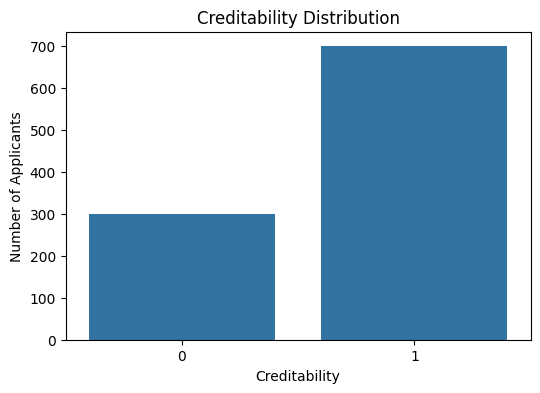

In [8]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="Creditability")

plt.title("Creditability Distribution")
plt.xlabel("Creditability")
plt.ylabel("Number of Applicants")
plt.show()

In [9]:
print("Missing values:")
print(df.isnull().sum().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

Missing values:
0

Duplicate rows:
0


In [10]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Creditability,1000.0,0.700,0.458487,0.0,0.0,1.0,1.00,1.0
Status of exsiting checking amount,1000.0,2.577,1.257638,1.0,1.0,2.0,4.00,4.0
Duration of Credit (month),1000.0,20.903,12.058814,4.0,12.0,18.0,24.00,72.0
Credit History,1000.0,2.545,1.083120,0.0,2.0,2.0,4.00,4.0
Purpose,1000.0,2.828,2.744439,0.0,1.0,2.0,3.00,10.0
Credit Amount,1000.0,3271.248,2822.751760,250.0,1365.5,2319.5,3972.25,18424.0
Savings account/bonds,1000.0,2.105,1.580023,1.0,1.0,1.0,3.00,5.0
Present employement since,1000.0,3.384,1.208306,1.0,3.0,3.0,5.00,5.0
Installment percent,1000.0,2.973,1.118715,1.0,2.0,3.0,4.00,4.0
Sex & Marital Status,1000.0,2.682,0.708080,1.0,2.0,3.0,3.00,4.0


In [11]:
df["Credit_Risk"] = df["Creditability"].map({
    0: "Bad",
    1: "Good"
})

df["Credit_Risk"].value_counts()

Credit_Risk
Good    700
Bad     300
Name: count, dtype: int64

In [12]:
#grouping data for simple analysis
df["Age_Group"] = pd.cut(
    df["Age (years)"],
    bins=[18, 25, 40, 60, np.inf],
    labels=["19-25", "26-40", "41-60", "60+"],
    include_lowest=True
)

df["Credit_Amount_Group"] = pd.cut(
    df["Credit Amount"],
    bins=[0, 1000, 5000, 10000, np.inf],
    labels=["<1000", "1000-5000", "5000-10000", "10000+"],
    include_lowest=True
)

df["Duration_Group"] = pd.cut(
    df["Duration of Credit (month)"],
    bins=[0, 12, 18, 24, np.inf],
    labels=["<=12", "13-18", "19-24", "25+"],
    include_lowest=True
)

In [13]:
age_risk = pd.crosstab(
    df["Age_Group"],
    df["Credit_Risk"],
    normalize="index"
) * 100

age_risk.round(2)

Credit_Risk,Bad,Good
Age_Group,,
19-25,42.11,57.89
26-40,27.51,72.49
41-60,27.31,72.69
60+,22.22,77.78


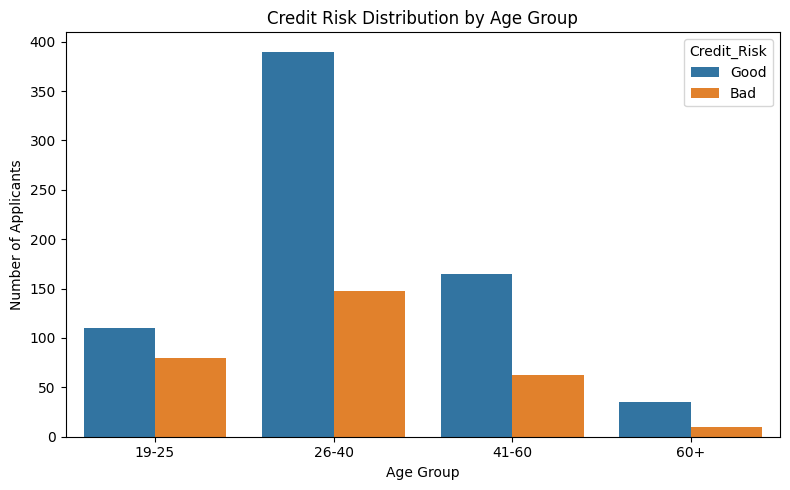

In [14]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Age_Group",
    hue="Credit_Risk"
)

plt.title("Credit Risk Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Applicants")
plt.tight_layout()
plt.show()

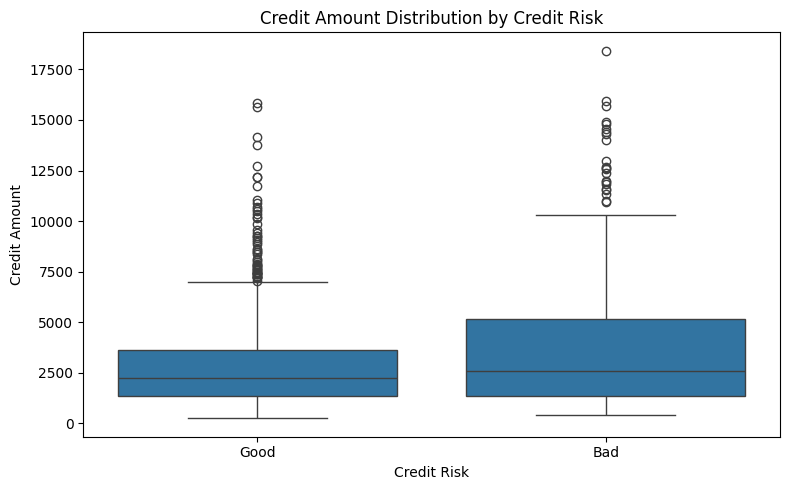

In [15]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Credit_Risk",
    y="Credit Amount"
)

plt.title("Credit Amount Distribution by Credit Risk")
plt.xlabel("Credit Risk")
plt.ylabel("Credit Amount")
plt.tight_layout()
plt.show()

In [16]:
credit_risk = pd.crosstab(
    df["Credit_Amount_Group"],
    df["Credit_Risk"],
    normalize="index"
) * 100

credit_risk.round(2)

Credit_Risk,Bad,Good
Credit_Amount_Group,,
<1000,31.90,68.10
1000-5000,26.58,73.42
5000-10000,36.49,63.51
10000+,60.00,40.00


In [17]:
duration_risk = pd.crosstab(
    df["Duration_Group"],
    df["Credit_Risk"],
    normalize="index"
) * 100

duration_risk.round(2)

Credit_Risk,Bad,Good
Duration_Group,,
<=12,21.17,78.83
13-18,29.95,70.05
19-24,29.46,70.54
25+,44.35,55.65


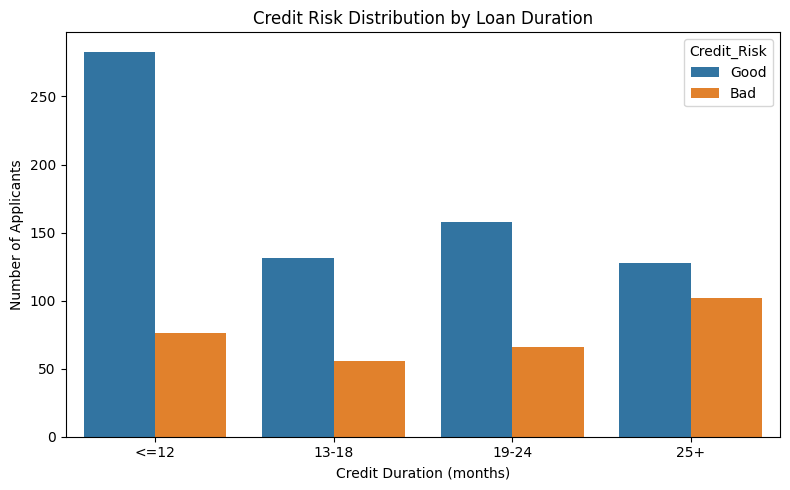

In [18]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Duration_Group",
    hue="Credit_Risk"
)

plt.title("Credit Risk Distribution by Loan Duration")
plt.xlabel("Credit Duration (months)")
plt.ylabel("Number of Applicants")
plt.tight_layout()
plt.show()

In [19]:
savings_risk = pd.crosstab(
    df["Savings account/bonds"],
    df["Credit_Risk"],
    normalize="index"
) * 100

savings_risk.round(2)

Credit_Risk,Bad,Good
Savings account/bonds,,
1,35.99,64.01
2,33.01,66.99
3,17.46,82.54
4,12.50,87.50
5,17.49,82.51


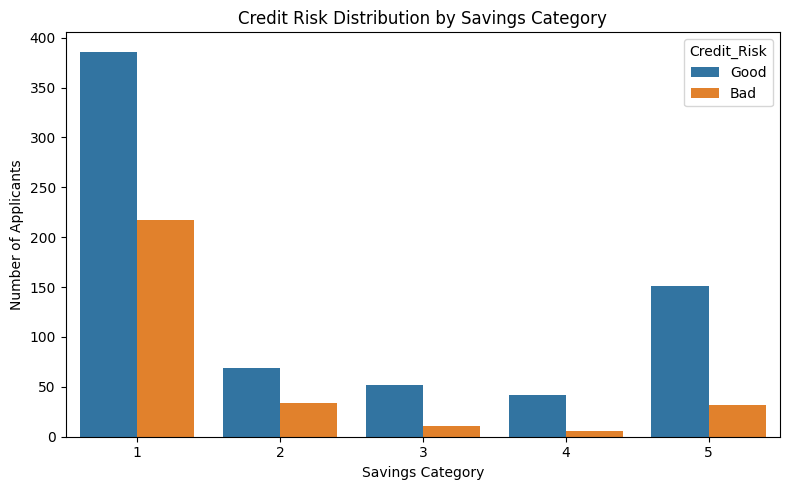

In [20]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Savings account/bonds",
    hue="Credit_Risk"
)

plt.title("Credit Risk Distribution by Savings Category")
plt.xlabel("Savings Category")
plt.ylabel("Number of Applicants")
plt.tight_layout()
plt.show()

In [21]:
occupation_risk = pd.crosstab(
    df["Occupation"],
    df["Credit_Risk"],
    normalize="index"
) * 100

occupation_risk.round(2)

Credit_Risk,Bad,Good
Occupation,,
1,31.82,68.18
2,28.00,72.00
3,29.52,70.48
4,34.46,65.54


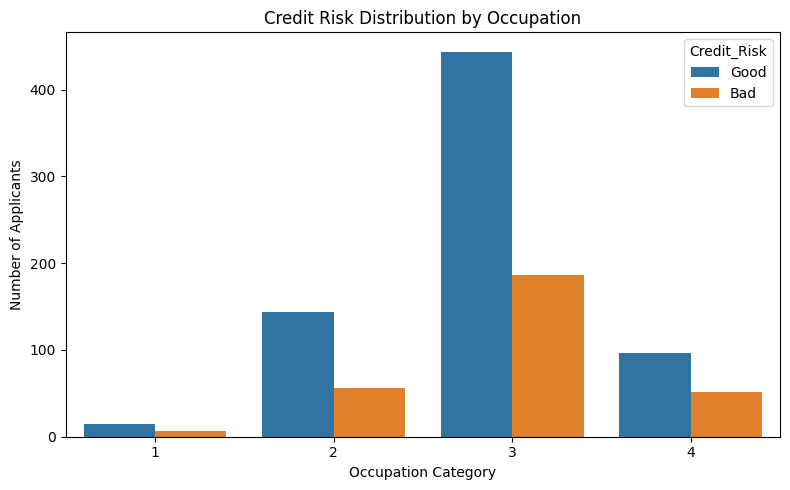

In [22]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Occupation",
    hue="Credit_Risk"
)

plt.title("Credit Risk Distribution by Occupation")
plt.xlabel("Occupation Category")
plt.ylabel("Number of Applicants")
plt.tight_layout()
plt.show()

In [23]:
categorical_features = [
    "Status of exsiting checking amount",
    "Credit History",
    "Purpose",
    "Savings account/bonds",
    "Present employement since",
    "Installment percent",
    "Sex & Marital Status",
    "Guarantors",
    "Present Residence since",
    "Property",
    "Other installment plans",
    "Type of apartment",
    "No of Credits at this Bank",
    "Occupation",
    "No of dependents",
    "Telephone",
    "Foreign Worker"
]

risk_summary = []

for feature in categorical_features:
    temp = (
        df.groupby(feature)["Creditability"]
        .agg(["count", "mean"])
        .reset_index()
    )
    
    temp["Bad_Credit_Rate_%"] = (1 - temp["mean"]) * 100
    temp["Feature"] = feature
    
    risk_summary.append(temp)

risk_summary = pd.concat(risk_summary, ignore_index=True)

risk_summary[
    ["Feature", categorical_features[0], "count", "Bad_Credit_Rate_%"]
].head()

,Feature,Status of exsiting checking amount,count,Bad_Credit_Rate_%
0,Status of exsiting checking amount,1.0,274,49.270073
1,Status of exsiting checking amount,2.0,269,39.033457
2,Status of exsiting checking amount,3.0,63,22.222222
3,Status of exsiting checking amount,4.0,394,11.675127
4,Credit History,NaN,40,62.500000


In [24]:
risk_summary = []

for feature in categorical_features:
    temp = df.groupby(feature)["Creditability"].agg(
        Applicants="count",
        Good_Credit_Rate="mean"
    ).reset_index()
    
    temp["Bad_Credit_Rate"] = (1 - temp["Good_Credit_Rate"]) * 100
    temp["Feature"] = feature
    
    risk_summary.append(temp)

risk_summary = pd.concat(risk_summary, ignore_index=True)

risk_summary.head(15)

,Status of exsiting checking amount,Applicants,Good_Credit_Rate,Bad_Credit_Rate,Feature,Credit History,Purpose,Savings account/bonds,Present employement since,Installment percent,Sex & Marital Status,Guarantors,Present Residence since,Property,Other installment plans,Type of apartment,No of Credits at this Bank,Occupation,No of dependents,Telephone,Foreign Worker
0,1.0,274,0.507299,49.270073,Status of exsiting checking amount,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2.0,269,0.609665,39.033457,Status of exsiting checking amount,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3.0,63,0.777778,22.222222,Status of exsiting checking amount,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4.0,394,0.883249,11.675127,Status of exsiting checking amount,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,40,0.375000,62.500000,Credit History,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,49,0.428571,57.142857,Credit History,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,NaN,530,0.681132,31.886792,Credit History,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,88,0.681818,31.818182,Credit History,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,NaN,293,0.829352,17.064846,Credit History,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,NaN,234,0.619658,38.034188,Purpose,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [25]:
numerical_features = [
    "Duration of Credit (month)",
    "Credit Amount",
    "Age (years)"
]

df.groupby("Credit_Risk")[numerical_features].mean().round(2)

,Duration of Credit (month),Credit Amount,Age (years)
Credit_Risk,,,
Bad,24.86,3938.13,33.96
Good,19.21,2985.44,36.22


In [26]:
df.groupby("Credit_Risk")[numerical_features].median().round(2)

,Duration of Credit (month),Credit Amount,Age (years)
Credit_Risk,,,
Bad,24.0,2574.5,31.0
Good,18.0,2244.0,34.0


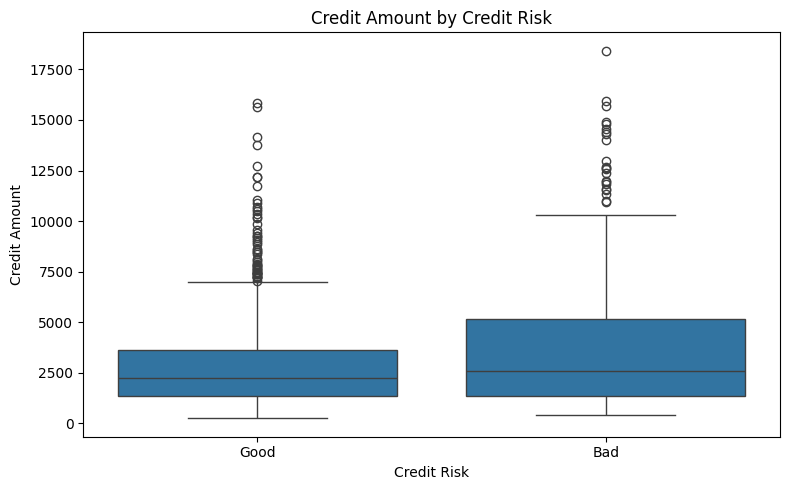

In [27]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Credit_Risk",
    y="Credit Amount"
)

plt.title("Credit Amount by Credit Risk")
plt.xlabel("Credit Risk")
plt.ylabel("Credit Amount")

plt.tight_layout()
plt.show()

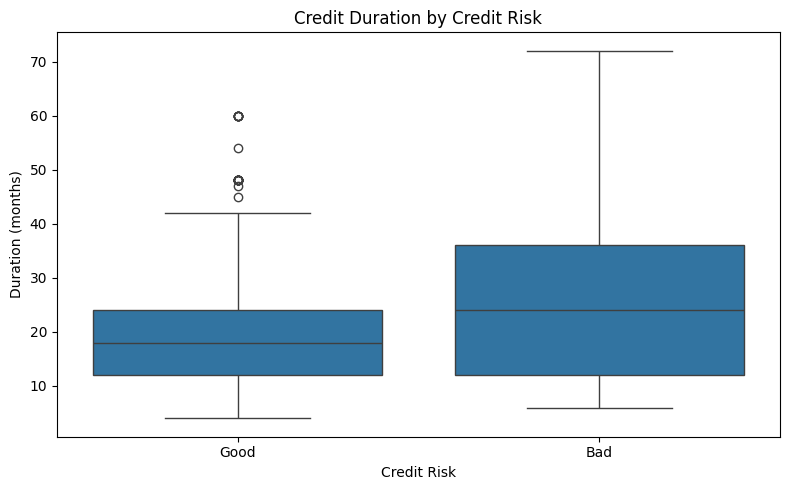

In [28]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Credit_Risk",
    y="Duration of Credit (month)"
)

plt.title("Credit Duration by Credit Risk")
plt.xlabel("Credit Risk")
plt.ylabel("Duration (months)")

plt.tight_layout()
plt.show()

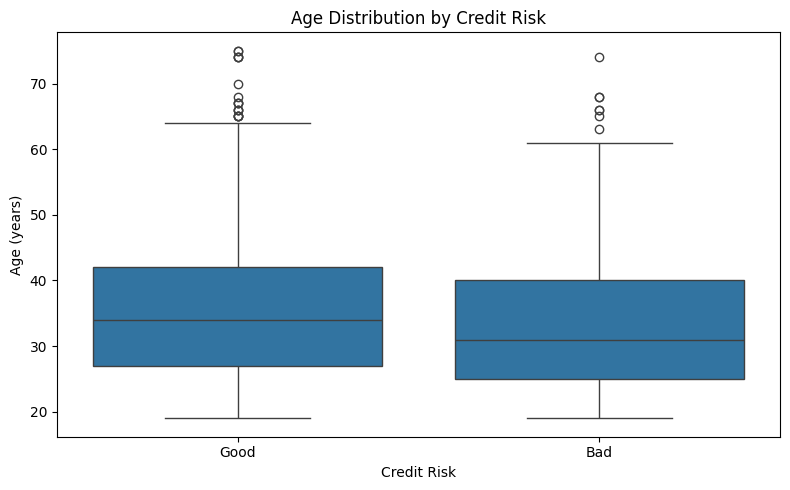

In [29]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Credit_Risk",
    y="Age (years)"
)

plt.title("Age Distribution by Credit Risk")
plt.xlabel("Credit Risk")
plt.ylabel("Age (years)")

plt.tight_layout()
plt.show()

In [30]:
risk_rate_tables = {}

for feature in categorical_features:
    risk_rate = (
        df.groupby(feature)["Creditability"]
        .apply(lambda x: (x == 0).mean() * 100)
        .round(2)
        .reset_index(name="Bad_Credit_Rate_%")
    )
    
    risk_rate_tables[feature] = risk_rate

In [31]:
risk_rate_tables["Status of exsiting checking amount"]

,Status of exsiting checking amount,Bad_Credit_Rate_%
0,1,49.27
1,2,39.03
2,3,22.22
3,4,11.68


In [32]:
risk_rate_tables["Credit History"]

,Credit History,Bad_Credit_Rate_%
0,0,62.50
1,1,57.14
2,2,31.89
3,3,31.82
4,4,17.06


In [33]:
risk_rate_tables["Savings account/bonds"]

,Savings account/bonds,Bad_Credit_Rate_%
0,1,35.99
1,2,33.01
2,3,17.46
3,4,12.50
4,5,17.49


In [34]:
risk_rate_tables["Purpose"]

,Purpose,Bad_Credit_Rate_%
0,0,38.03
1,1,16.50
2,2,32.04
3,3,22.14
4,4,33.33
5,5,36.36
6,6,44.00
7,8,11.11
8,9,35.05
9,10,41.67


In [35]:
risk_rate_tables["Present employement since"]

,Present employement since,Bad_Credit_Rate_%
0,1,37.10
1,2,40.70
2,3,30.68
3,4,22.41
4,5,25.30


In [36]:
risk_rate_tables["Property"]

,Property,Bad_Credit_Rate_%
0,1,21.28
1,2,30.60
2,3,30.72
3,4,43.51


In [37]:
risk_rate_tables["Occupation"]

,Occupation,Bad_Credit_Rate_%
0,1,31.82
1,2,28.00
2,3,29.52
3,4,34.46


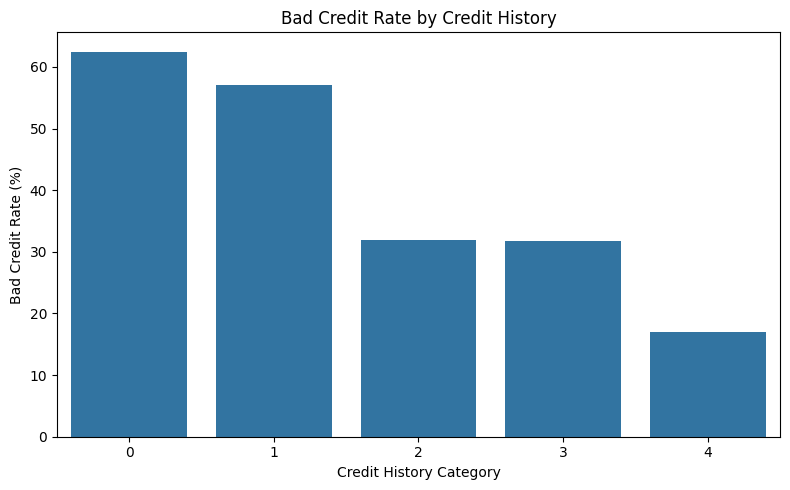

In [38]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=risk_rate_tables["Credit History"],
    x="Credit History",
    y="Bad_Credit_Rate_%"
)

plt.title("Bad Credit Rate by Credit History")
plt.xlabel("Credit History Category")
plt.ylabel("Bad Credit Rate (%)")
plt.tight_layout()
plt.show()

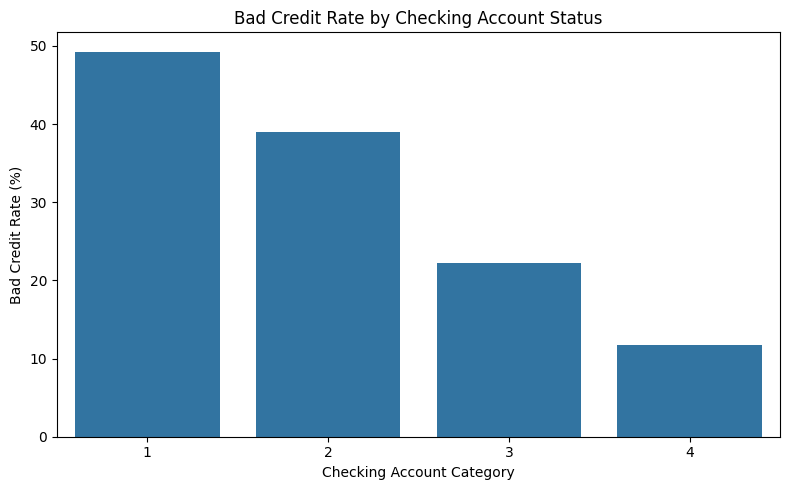

In [39]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=risk_rate_tables["Status of exsiting checking amount"],
    x="Status of exsiting checking amount",
    y="Bad_Credit_Rate_%"
)

plt.title("Bad Credit Rate by Checking Account Status")
plt.xlabel("Checking Account Category")
plt.ylabel("Bad Credit Rate (%)")
plt.tight_layout()
plt.show()

In [40]:
from scipy.stats import chi2_contingency
chi_square_results = []

for feature in categorical_features:
    contingency_table = pd.crosstab(
        df[feature],
        df["Creditability"]
    )
    
    chi2, p_value, dof, expected = chi2_contingency(contingency_table)
    
    chi_square_results.append({
        "Feature": feature,
        "Chi2": chi2,
        "p_value": p_value,
        "Degrees_of_Freedom": dof
    })

chi_square_results = pd.DataFrame(chi_square_results)

chi_square_results = chi_square_results.sort_values(
    "p_value"
)

chi_square_results.round(4)

,Feature,Chi2,p_value,Degrees_of_Freedom
0,Status of exsiting checking amount,123.7209,0.0000,3
1,Credit History,61.6914,0.0000,4
3,Savings account/bonds,36.0989,0.0000,4
9,Property,23.7196,0.0000,3
11,Type of apartment,18.6740,0.0001,2
2,Purpose,33.3564,0.0001,9
4,Present employement since,18.3683,0.0010,4
10,Other installment plans,12.8392,0.0016,2
16,Foreign Worker,5.8216,0.0158,1
6,Sex & Marital Status,9.6052,0.0222,3


In [41]:
chi_square_results["Significant"] = np.where(
    chi_square_results["p_value"] < 0.05,
    "Yes",
    "No"
)

chi_square_results.round(4)

,Feature,Chi2,p_value,Degrees_of_Freedom,Significant
0,Status of exsiting checking amount,123.7209,0.0000,3,Yes
1,Credit History,61.6914,0.0000,4,Yes
3,Savings account/bonds,36.0989,0.0000,4,Yes
9,Property,23.7196,0.0000,3,Yes
11,Type of apartment,18.6740,0.0001,2,Yes
2,Purpose,33.3564,0.0001,9,Yes
4,Present employement since,18.3683,0.0010,4,Yes
10,Other installment plans,12.8392,0.0016,2,Yes
16,Foreign Worker,5.8216,0.0158,1,Yes
6,Sex & Marital Status,9.6052,0.0222,3,Yes


In [43]:
from scipy.stats import mannwhitneyu
numerical_test_results = []

for feature in numerical_features:
    good = df.loc[
        df["Creditability"] == 1,
        feature
    ]
    
    bad = df.loc[
        df["Creditability"] == 0,
        feature
    ]
    
    statistic, p_value = mannwhitneyu(
        good,
        bad,
        alternative="two-sided"
    )
    
    numerical_test_results.append({
        "Feature": feature,
        "U_Statistic": statistic,
        "p_value": p_value
    })

numerical_test_results = pd.DataFrame(
    numerical_test_results
).sort_values("p_value")

numerical_test_results.round(4)

,Feature,U_Statistic,p_value
0,Duration of Credit (month),77995.5,0.0000
2,Age (years),119971.5,0.0003
1,Credit Amount,93480.0,0.0059


In [44]:
checking_rates = risk_rate_tables[
    "Status of exsiting checking amount"
].copy()

checking_rates

,Status of exsiting checking amount,Bad_Credit_Rate_%
0,1,49.27
1,2,39.03
2,3,22.22
3,4,11.68


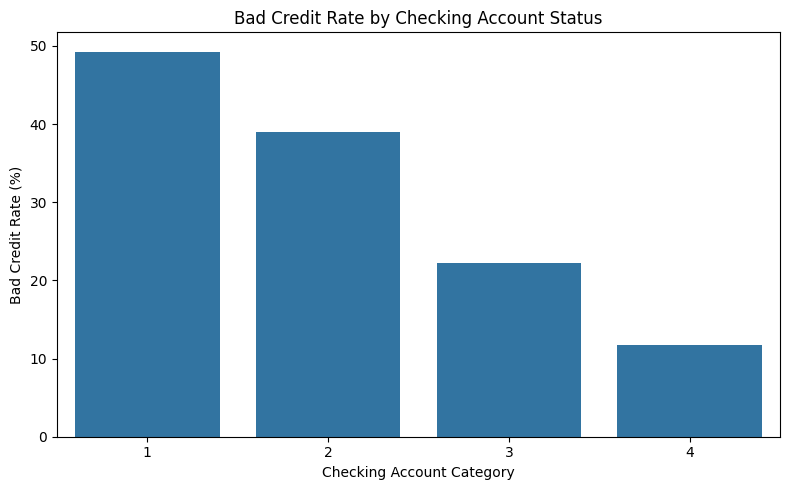

In [45]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=checking_rates,
    x="Status of exsiting checking amount",
    y="Bad_Credit_Rate_%"
)

plt.title("Bad Credit Rate by Checking Account Status")
plt.xlabel("Checking Account Category")
plt.ylabel("Bad Credit Rate (%)")
plt.tight_layout()
plt.show()

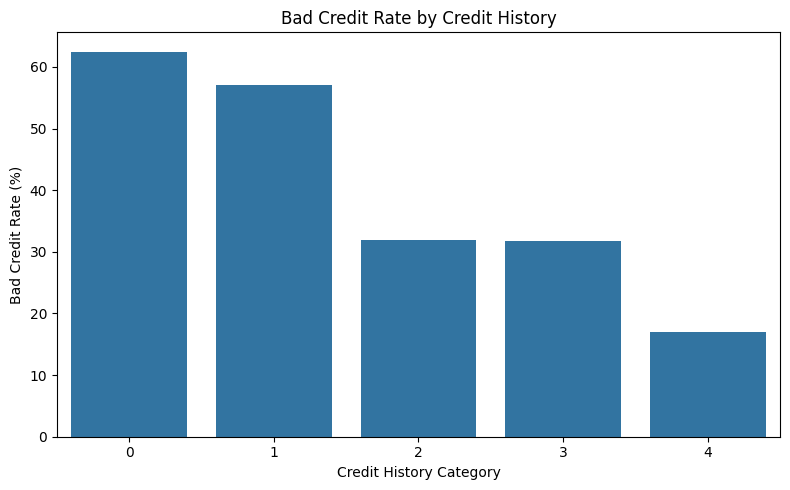

In [46]:
history_rates = risk_rate_tables["Credit History"].copy()

plt.figure(figsize=(8, 5))

sns.barplot(
    data=history_rates,
    x="Credit History",
    y="Bad_Credit_Rate_%"
)

plt.title("Bad Credit Rate by Credit History")
plt.xlabel("Credit History Category")
plt.ylabel("Bad Credit Rate (%)")
plt.tight_layout()
plt.show()

In [47]:
from scipy.stats import chi2_contingency
cramers_v_results = []

for feature in categorical_features:
    contingency_table = pd.crosstab(
        df[feature],
        df["Creditability"]
    )
    
    chi2, p_value, dof, expected = chi2_contingency(
        contingency_table
    )
    
    n = contingency_table.sum().sum()
    r, k = contingency_table.shape
    
    cramers_v = np.sqrt(
        chi2 / (n * min(k - 1, r - 1))
    )
    
    cramers_v_results.append({
        "Feature": feature,
        "Chi2": chi2,
        "p_value": p_value,
        "Cramers_V": cramers_v
    })

cramers_v_results = pd.DataFrame(
    cramers_v_results
).sort_values(
    "Cramers_V",
    ascending=False
)

cramers_v_results.round(4)

,Feature,Chi2,p_value,Cramers_V
0,Status of exsiting checking amount,123.7209,0.0000,0.3517
1,Credit History,61.6914,0.0000,0.2484
3,Savings account/bonds,36.0989,0.0000,0.1900
2,Purpose,33.3564,0.0001,0.1826
9,Property,23.7196,0.0000,0.1540
11,Type of apartment,18.6740,0.0001,0.1367
4,Present employement since,18.3683,0.0010,0.1355
10,Other installment plans,12.8392,0.0016,0.1133
6,Sex & Marital Status,9.6052,0.0222,0.0980
7,Guarantors,6.6454,0.0361,0.0815


In [48]:
checking_map = {
    1: "< 0 DM",
    2: "0 to < 200 DM",
    3: ">= 200 DM",
    4: "No checking account"
}

df["Checking_Status"] = df[
    "Status of exsiting checking amount"
].map(checking_map)

In [49]:
credit_history_map = {
    0: "No credits / all paid",
    1: "All credits paid",
    2: "Existing credits paid duly",
    3: "Delay in paying previous credits",
    4: "Critical / other existing credits"
}

df["Credit_History_Label"] = df[
    "Credit History"
].map(credit_history_map)

In [50]:
savings_map = {
    1: "< 100 DM",
    2: "100 to < 500 DM",
    3: "500 to < 1000 DM",
    4: ">= 1000 DM",
    5: "Unknown / no savings account"
}

df["Savings_Label"] = df[
    "Savings account/bonds"
].map(savings_map)

In [51]:
property_map = {
    1: "Real estate",
    2: "Building society savings / life insurance",
    3: "Car or other",
    4: "Unknown / no property"
}

df["Property_Label"] = df[
    "Property"
].map(property_map)

In [52]:
apartment_map = {
    1: "Rent",
    2: "Own",
    3: "Free / other"
}

df["Apartment_Label"] = df[
    "Type of apartment"
].map(apartment_map)

In [53]:
df[
    [
        "Checking_Status",
        "Credit_History_Label",
        "Savings_Label",
        "Property_Label",
        "Apartment_Label"
    ]
].head(10)

,Checking_Status,Credit_History_Label,Savings_Label,Property_Label,Apartment_Label
0,< 0 DM,Critical / other existing credits,< 100 DM,Building society savings / life insurance,Rent
1,< 0 DM,Critical / other existing credits,< 100 DM,Real estate,Rent
2,0 to < 200 DM,Existing credits paid duly,100 to < 500 DM,Real estate,Rent
3,< 0 DM,Critical / other existing credits,< 100 DM,Real estate,Rent
4,< 0 DM,Critical / other existing credits,< 100 DM,Building society savings / life insurance,Own
5,< 0 DM,Critical / other existing credits,< 100 DM,Real estate,Rent
6,< 0 DM,Critical / other existing credits,< 100 DM,Real estate,Own
7,< 0 DM,Critical / other existing credits,< 100 DM,Real estate,Own
8,No checking account,Critical / other existing credits,< 100 DM,Car or other,Own
9,0 to < 200 DM,Existing credits paid duly,500 to < 1000 DM,Unknown / no property,Rent


In [54]:
history_labeled = pd.crosstab(
    df["Credit_History_Label"],
    df["Credit_Risk"],
    normalize="index"
) * 100

history_labeled.round(2)

Credit_Risk,Bad,Good
Credit_History_Label,,
All credits paid,57.14,42.86
Critical / other existing credits,17.06,82.94
Delay in paying previous credits,31.82,68.18
Existing credits paid duly,31.89,68.11
No credits / all paid,62.50,37.50


In [55]:
checking_labeled = pd.crosstab(
    df["Checking_Status"],
    df["Credit_Risk"],
    normalize="index"
) * 100

checking_labeled.round(2)

Credit_Risk,Bad,Good
Checking_Status,,
0 to < 200 DM,39.03,60.97
< 0 DM,49.27,50.73
>= 200 DM,22.22,77.78
No checking account,11.68,88.32


In [56]:
savings_labeled = pd.crosstab(
    df["Savings_Label"],
    df["Credit_Risk"],
    normalize="index"
) * 100

savings_labeled.round(2)

Credit_Risk,Bad,Good
Savings_Label,,
100 to < 500 DM,33.01,66.99
500 to < 1000 DM,17.46,82.54
< 100 DM,35.99,64.01
>= 1000 DM,12.50,87.50
Unknown / no savings account,17.49,82.51


In [58]:
# Target: 1 = Bad Credit, 0 = Good Credit
# Target: 1 = Bad Credit, 0 = Good Credit
y = (df["Creditability"] == 0).astype(int)

# Use only the original predictor columns
original_features = [
    "Status of exsiting checking amount",
    "Duration of Credit (month)",
    "Credit History",
    "Purpose",
    "Credit Amount",
    "Savings account/bonds",
    "Present employement since",
    "Installment percent",
    "Sex & Marital Status",
    "Guarantors",
    "Present Residence since",
    "Property",
    "Age (years)",
    "Other installment plans",
    "Type of apartment",
    "No of Credits at this Bank",
    "Occupation",
    "No of dependents",
    "Telephone",
    "Foreign Worker"
]

X = df[original_features].copy()

print("Features:", X.shape)
print("Target:", y.shape)

Features: (1000, 20)
Target: (1000,)


In [59]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True).round(3))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True).round(3))

Training samples: 800
Testing samples: 200

Training target distribution:
Creditability
0    0.7
1    0.3
Name: proportion, dtype: float64

Testing target distribution:
Creditability
0    0.7
1    0.3
Name: proportion, dtype: float64


In [60]:
numerical_features = [
    "Duration of Credit (month)",
    "Credit Amount",
    "Age (years)"
]

categorical_features_model = [
    col for col in X.columns
    if col not in numerical_features
]

print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features_model)

Numerical features:
['Duration of Credit (month)', 'Credit Amount', 'Age (years)']

Categorical features:
['Status of exsiting checking amount', 'Credit History', 'Purpose', 'Savings account/bonds', 'Present employement since', 'Installment percent', 'Sex & Marital Status', 'Guarantors', 'Present Residence since', 'Property', 'Other installment plans', 'Type of apartment', 'No of Credits at this Bank', 'Occupation', 'No of dependents', 'Telephone', 'Foreign Worker']


In [61]:
from sklearn.preprocessing import StandardScaler
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            StandardScaler(),
            numerical_features
        ),
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features_model
        )
    ]
)

In [62]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=5,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=8,
        random_state=42,
        class_weight="balanced"
    )
}

In [63]:
pipelines = {}

for name, model in models.items():
    pipelines[name] = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )

In [64]:
for name, pipeline in pipelines.items():
    pipeline.fit(X_train, y_train)
    print(f"{name} trained successfully.")

Logistic Regression trained successfully.
Decision Tree trained successfully.
Random Forest trained successfully.


In [65]:
results = []

for name, pipeline in pipelines.items():
    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    "ROC-AUC",
    ascending=False
).reset_index(drop=True)

results_df.round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Random Forest,0.735,0.5614,0.5333,0.5470,0.7670
1,Logistic Regression,0.740,0.5909,0.4333,0.5000,0.7418
2,Decision Tree,0.715,0.5385,0.3500,0.4242,0.6851


In [66]:
best_model_name = "Random Forest"
best_model = pipelines[best_model_name]

y_pred_rf = best_model.predict(X_test)

print(classification_report(
    y_test,
    y_pred_rf,
    target_names=["Good Credit", "Bad Credit"]
))

              precision    recall  f1-score   support

 Good Credit       0.80      0.82      0.81       140
  Bad Credit       0.56      0.53      0.55        60

    accuracy                           0.73       200
   macro avg       0.68      0.68      0.68       200
weighted avg       0.73      0.73      0.73       200



In [67]:
cm = confusion_matrix(y_test, y_pred_rf)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[115  25]
 [ 28  32]]


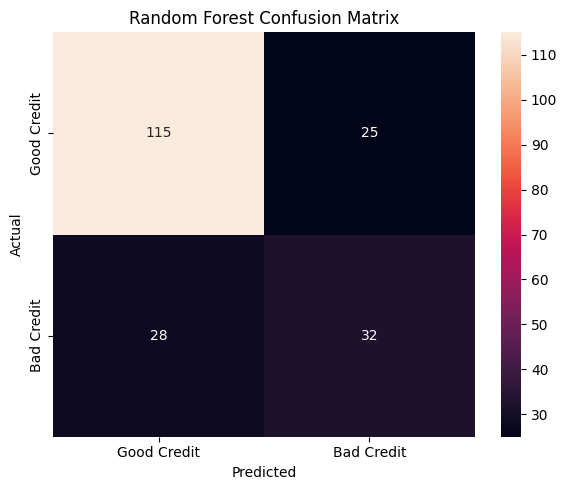

In [68]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Good Credit", "Bad Credit"],
    yticklabels=["Good Credit", "Bad Credit"]
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()